# Ноутбуки для GitHub. 
---

## Тема 2 - Моделирование связи частотного и классического определения вероятности
---

In [2]:
from math import pi, sqrt
from itertools import product
from matplotlib.patches import Circle, Rectangle
from numpy.random import uniform
import matplotlib.pyplot as plt
import numpy as np

### Задача
> Приведите пример, показывающий связь частотного и классического определения вероятности с помощью моделирования (на примере задачи про красно-синие шары или задачи о сумме очков на двух кубиках). Графически показать стремление частотной вероятности к классической при увеличении числа опытов.


* Кубики симметричны, поэтому все пары равновозможны: $$n = 6 \cdot 6 = 36$$
Пусть событию $A$ — сумма очков равна 7 — благоприятствуют исходы $(1,6), (2,5), (3,4), (4,3), (5,2), (6,1)$, то есть $m = 6$.

* По классическому определению вероятности: $$P(A) = \frac{m}{n} = \frac{6}{36} = \boxed{\frac{1}{6} \approx 0{,}1667}$$

* Частотная вероятность события $A$ — доля опытов, в которых оно произошло: $$P^*(A) = \frac{m_N}{N}$$
Из моделирования видно, что при увеличении числа опытов частотная вероятность приближается к классической. Классическая вероятность — это предельный случай бесконечного числа экспериментов.

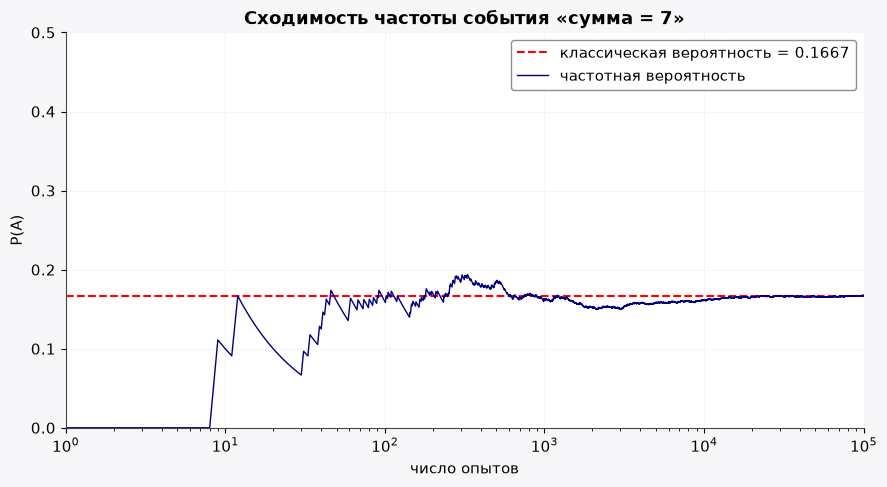

In [8]:
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.edgecolor': '#444444',
    'figure.facecolor': '#f7f7f9',
    'axes.facecolor': '#ffffff',
    'grid.color': '#cccccc',
})

target = 7
rng = np.random.default_rng(52)
ls = list(product('123456', repeat=2))
prob = {}
for pair in ls:
    sum_ = sum(list(map(int, pair)))
    prob[sum_] = prob.get(sum_, 0) + 1
N = len(ls)
prob = {sum_: count / N for sum_, count in prob.items()}
P_theor, P_freq = prob[target], {}

for n in 100, 1000, 10000, 100000, 1000000:
    s = rng.integers(1, 7, n) + rng.integers(1, 7, n)
    m = int(np.sum(s == target))
    P_freq[n] = m / n
    
n_max = 100000
s = rng.integers(1, 7, n_max) + rng.integers(1, 7, n_max)
freq = np.cumsum(s == target) / np.arange(1, n_max + 1)

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(1, n_max + 1)
sigma = np.sqrt(P_theor * (1 - P_theor) / x)

ax.axhline(P_theor, c='red', ls='--', lw=1.5,
           label=f'классическая вероятность = {P_theor:.4f}')

ax.plot(x, freq, lw=1.0, c='navy', label='частотная вероятность')

ax.set_xscale('log')
ax.set_ylim(0, 0.5)
ax.set_xlim(1, n_max)
ax.set_xlabel('число опытов')
ax.set_ylabel('P(A)')
ax.set_title(f'Сходимость частоты события «сумма на кубике = {target}»')
ax.grid(alpha=0.3, linestyle='--', linewidth=0.6)
ax.legend(loc='upper right', framealpha=0.95, edgecolor='#888888')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()